## Arkansas EI Analysis Using PyEI

In [11]:
import pandas as pd
import numpy as np
import json
import dill
from pyei.two_by_two import TwoByTwoEI
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

import os
os.environ["PYTENSOR_FLAGS"] = "cxx=,mode=FAST_COMPILE,linker=py"

import shutil
shutil.rmtree(os.path.expanduser("~\\AppData\\Local\\PyTensor"), ignore_errors=True)

### Path and DataFrame

In [2]:
path = '../output/Arkansas/seawulf.csv'

In [3]:
ar_df = pd.read_csv(path)
ar_df

,Unique_ID,COUNTYFP,Kamala D. Harris,Donald J. Trump,Other_candidates,Total_votes,White_population,Black_population,Latino_population,Other_population,Total_population,geometry
0,05001-81 - Stuttgart 2,1,293,639,19,951,486.169395,356.604974,32.728840,0.738939,876.242147,MULTIPOLYGON (((-91.5231316857873 34.478810237...
1,05001-36 - Gillett Ward 3,1,25,39,2,66,63.524419,10.565301,0.982819,2.213607,77.286145,MULTIPOLYGON (((-91.38939074391136 34.11619766...
2,05001-53 - Dewitt 2,1,49,188,5,242,230.348940,133.055168,0.119868,4.781286,368.305262,MULTIPOLYGON (((-91.32906069811533 34.28233664...
3,05001-51 - DeWitt 1,1,101,61,5,167,332.713262,201.772191,0.000000,7.098115,541.583568,MULTIPOLYGON (((-91.32906069811533 34.28233664...
4,05001-55 - Dewitt 3,1,42,272,3,317,36.167855,9.010094,0.713321,0.281977,46.173247,MULTIPOLYGON (((-91.34061668009974 34.30202646...
...,...,...,...,...,...,...,...,...,...,...,...,...
2676,05149-10 - Dardanelle Ward 3,149,59,93,5,157,242.266509,33.762641,53.156670,23.501428,352.687248,MULTIPOLYGON (((-93.15994530244187 35.21329777...
2677,05149-18 - Magazine 1,149,79,354,7,440,763.771656,0.000000,69.264875,45.229594,878.266125,MULTIPOLYGON (((-93.27993201914387 35.21255732...
2678,05149-29 - Ions Creek,149,0,19,0,19,141.619378,2.686534,2.302779,13.816510,160.425201,MULTIPOLYGON (((-93.7087501822021 34.833043511...
2679,05149-24 - Waveland,149,18,69,1,88,253.901601,7.571889,4.456923,9.800575,275.730988,MULTIPOLYGON (((-93.59986763465503 35.14712613...


### Isolate Columns Needed + Create Columns Necessary

[Source](https://github.com/mggg/ecological-inference/blob/main/pyei/intro_notebooks/PyEI_overview.ipynb?short_path=f3688a3)

Whether you are using an example data set or your own data, here is what you will need to pass to the various EI methods:

A vector of length `num_precincts` giving the population of each precincts. Depending on your purposes and data, the appropriate measure of population may be CVAP, VAP, etc. Below we name this `precinct_pops`.

For 2 x 2 EI:

- A vector of length `num_precincts` whose entries are each numbers between zero and 1 that give the fraction of the population of each precinct who belong to the demographic group of interest. Below we name this `group_fraction`.
- A vector of length `num_precincts` whose entries are each numbers beteween zero and 1 that give the fraction of voters in each precinct voting for the candidate of interest (or, if we are estimating turnout, who voted at all). Below, we name this `votes_fraction`.
Optionally: name of the candidate of interest, name of the demographic group of interest, and/or names of precincts (for use in PyEI's plotting and reporting).

In [ ]:
demographics = ['white', 'black', 'latino', 'other']
candidates = ['harris', 'trump']
ar_df.columns = ar_df.columns.str.lower()

ar_data = ar_df[['unique_id', 'kamala d. harris', 'donald j. trump', 'total_votes', 
                 'white_population', 'black_population', 'latino_population', 'other_population', 'total_population']]
ar_data = ar_data.rename(columns={'unique_id' : 'precincts', 'kamala d. harris' : 'harris', 'donald j. trump' : 'trump'})
ar_data['total'] = ar_data['harris'] + ar_data['trump']
ar_data

,precincts,harris,trump,total_votes,white_population,black_population,latino_population,other_population,total_population,total
0,05001-81 - Stuttgart 2,293,639,951,486.169395,356.604974,32.728840,0.738939,876.242147,932
1,05001-36 - Gillett Ward 3,25,39,66,63.524419,10.565301,0.982819,2.213607,77.286145,64
2,05001-53 - Dewitt 2,49,188,242,230.348940,133.055168,0.119868,4.781286,368.305262,237
3,05001-51 - DeWitt 1,101,61,167,332.713262,201.772191,0.000000,7.098115,541.583568,162
4,05001-55 - Dewitt 3,42,272,317,36.167855,9.010094,0.713321,0.281977,46.173247,314
...,...,...,...,...,...,...,...,...,...,...
2676,05149-10 - Dardanelle Ward 3,59,93,157,242.266509,33.762641,53.156670,23.501428,352.687248,152
2677,05149-18 - Magazine 1,79,354,440,763.771656,0.000000,69.264875,45.229594,878.266125,433
2678,05149-29 - Ions Creek,0,19,19,141.619378,2.686534,2.302779,13.816510,160.425201,19
2679,05149-24 - Waveland,18,69,88,253.901601,7.571889,4.456923,9.800575,275.730988,87


In [5]:
def calculate_shares(df):
    result = df[['precincts', 'total']].copy()

    for demographic in demographics:
        result[f'{demographic}_pct'] = (
            df[f'{demographic}_population'] / df['total_population']
        )

    for candidate in candidates:
        result[f'{candidate}_pct'] = (
            df[candidate] / df['total_votes']
        )

    return result

In [6]:
data = calculate_shares(ar_data)
data.head()

,precincts,total,white_pct,black_pct,latino_pct,other_pct,harris_pct,trump_pct
0,05001-81 - Stuttgart 2,932,0.554835,0.406971,0.037351,0.000843,0.308097,0.671924
1,05001-36 - Gillett Ward 3,64,0.821938,0.136704,0.012717,0.028642,0.378788,0.590909
2,05001-53 - Dewitt 2,237,0.625429,0.361263,0.000325,0.012982,0.202479,0.776860
3,05001-51 - DeWitt 1,162,0.614334,0.372560,0.000000,0.013106,0.604790,0.365269
4,05001-55 - Dewitt 3,314,0.783308,0.195137,0.015449,0.006107,0.132492,0.858044


In [7]:
data.isna().any()

precincts     False
total         False
white_pct     False
black_pct     False
latino_pct    False
other_pct     False
harris_pct    False
trump_pct     False
dtype: bool

## Fitting Model

In [8]:
def fit_king_99(demographic, candidate):
    group_fraction = np.array(data[f"{demographic}_pct"])
    votes_fraction = np.array(data[f"{candidate}_pct"])

    precinct_pops = np.array(data["total"])
    precinct_names = data['precincts']

    ei = TwoByTwoEI(model_name="king99", lmbda=0.5)

    # Fit the model
    ei.fit(group_fraction, 
        votes_fraction, 
        precinct_pops, 
        demographic_group_name=demographic, 
        candidate_name=candidate, 
        precinct_names=precinct_names, 
        draws=1200, # optional
        tune=3000, # optional
        target_accept=.99 # optional
    )

    print(ei.summary())

    return ei


In [9]:
def fit_king_99_modif(demographic, candidate):
    group_fraction = np.array(data[f"{demographic}_pct"])
    votes_fraction = np.array(data[f"{candidate}_pct"])

    precinct_pops = np.array(data["total"])
    precinct_names = data['precincts']

    ei = TwoByTwoEI(model_name="king99_pareto_modification", pareto_scale=15, pareto_shape=2)

    # Fit the model
    ei.fit(group_fraction, 
        votes_fraction, 
        precinct_pops, 
        demographic_group_name=demographic, 
        candidate_name=candidate, 
        precinct_names=precinct_names, 
        draws=1200, # optional
        tune=3000, # optional
        target_accept=.99 # optional
    )

    print(ei.summary())

    return ei


In [12]:
models = {}

for candidate in candidates:
    models[candidate] = {}
    for demographic in demographics:
        ei = fit_king_99_modif(demographic, candidate)
        models[candidate][demographic] = ei

Compiling.. :   0%|          | 0/4200 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/4200 [00:03<?, ?it/s]


Running chain 0:   5%|▌         | 210/4200 [00:21<05:38, 11.78it/s]


Running chain 0:  10%|█         | 420/4200 [00:28<03:26, 18.27it/s]


Running chain 0:  15%|█▌        | 630/4200 [00:35<02:42, 21.97it/s]


Running chain 0:  20%|██        | 840/4200 [00:42<02:13, 25.22it/s]


Running chain 0:  25%|██▌       | 1050/4200 [00:49<01:59, 26.38it/s]


Running chain 0:  30%|███       | 1260/4200 [00:55<01:44, 28.12it/s]


Running chain 0:  35%|███▌      | 1470/4200 [01:02<01:33, 29.35it/s]


Running chain 0:  40%|████      | 1680/4200 [01:09<01:23, 30.16it/s]


Running chain 0:  45%|████▌     | 1890/4200 [01:15<01:14, 30.91it/s]


Running chain 0:  50%|█████     | 2100/4200 [01:21<01:06, 31.44it/s]


Running chain 0:  55%|█████▌    | 2310/4200 [01:28<00:59, 31.55it/s]


Running chain 0:  60%|██████    | 2520/4200 [01:34<00:52, 31.76it/s]


Running chain 0:  65%|██████▌   

Model: king99_pareto_modification
        Computed from the raw b_i samples by multiplying by population and then getting
        the proportion of the total pop (total pop=summed across all districts):
        The posterior mean for the district-level voting preference of
        white for harris is
        0.221
        The posterior mean for the district-level voting preference of
        non-white for harris is
        0.766
        95% equal-tailed Bayesian credible interval for district-level voting preference of
        white for harris is
        [0.21726838 0.22370506]
        95% equal-tailed Bayesian credible interval for district-level voting preference of
        non-white for harris is
        [0.75417889 0.77727138]
        


Compiling.. :   0%|          | 0/4200 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/4200 [00:03<?, ?it/s]


Running chain 0:   5%|▌         | 210/4200 [00:20<05:19, 12.48it/s]


Running chain 0:  10%|█         | 420/4200 [00:27<03:19, 18.97it/s]


Running chain 0:  15%|█▌        | 630/4200 [00:34<02:37, 22.64it/s]


Running chain 0:  20%|██        | 840/4200 [00:40<02:10, 25.71it/s]


Running chain 0:  25%|██▌       | 1050/4200 [00:47<01:55, 27.23it/s]


Running chain 0:  30%|███       | 1260/4200 [00:54<01:42, 28.59it/s]


Running chain 0:  35%|███▌      | 1470/4200 [01:00<01:31, 29.83it/s]


Running chain 0:  40%|████      | 1680/4200 [01:07<01:22, 30.45it/s]


Running chain 0:  45%|████▌     | 1890/4200 [01:13<01:14, 31.02it/s]


Running chain 0:  50%|█████     | 2100/4200 [01:20<01:08, 30.84it/s]


Running chain 0:  55%|█████▌    | 2310/4200 [01:27<01:00, 30.98it/s]


Running chain 0:  60%|██████    | 2520/4200 [01:34<00:54, 31.06it/s]


Running chain 0:  65%|██████▌   

Model: king99_pareto_modification
        Computed from the raw b_i samples by multiplying by population and then getting
        the proportion of the total pop (total pop=summed across all districts):
        The posterior mean for the district-level voting preference of
        black for harris is
        0.803
        The posterior mean for the district-level voting preference of
        non-black for harris is
        0.273
        95% equal-tailed Bayesian credible interval for district-level voting preference of
        black for harris is
        [0.79039671 0.81619398]
        95% equal-tailed Bayesian credible interval for district-level voting preference of
        non-black for harris is
        [0.27079162 0.27508766]
        


Compiling.. :   0%|          | 0/4200 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/4200 [00:03<?, ?it/s]





Running chain 0:  10%|█         | 420/4200 [00:31<04:00, 15.73it/s]





Running chain 0:  15%|█▌        | 630/4200 [00:43<03:40, 16.21it/s]


Running chain 0:  20%|██        | 840/4200 [00:55<03:22, 16.57it/s]


Running chain 0:  25%|██▌       | 1050/4200 [01:07<03:05, 16.94it/s]


Running chain 0:  30%|███       | 1260/4200 [01:19<02:52, 17.07it/s]





Running chain 0:  35%|███▌      | 1470/4200 [01:31<02:39, 17.10it/s]


Running chain 0:  40%|████      | 1680/4200 [01:44<02:28, 17.00it/s]


Running chain 0:  45%|████▌     | 1890/4200 [01:56<02:15, 17.05it/s]


Running chain 0:  50%|█████     | 2100/4200 [02:09<02:03, 17.03it/s]





Running chain 0:  55%|█████▌    | 2310/4200 [02:21<01:51, 16.97it/s]


Running chain 0:  60%|██████    | 2520/4200 [02:33<01:38, 16.99it/s]


Running chain 0:  65%|██████▌   | 2730/4200 [02:46<01:26, 17.01it/s]


Running chain 0:  7

...

Model: king99_pareto_modification
        Computed from the raw b_i samples by multiplying by population and then getting
        the proportion of the total pop (total pop=summed across all districts):
        The posterior mean for the district-level voting preference of
        black for trump is
        0.165
        The posterior mean for the district-level voting preference of
        non-black for trump is
        0.702
        95% equal-tailed Bayesian credible interval for district-level voting preference of
        black for trump is
        [0.1535814  0.17700947]
        95% equal-tailed Bayesian credible interval for district-level voting preference of
        non-black for trump is
        [0.7002034  0.70418684]
        


Compiling.. :   0%|          | 0/4200 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/4200 [00:03<?, ?it/s]





Running chain 0:   5%|▌         | 210/4200 [00:19<05:15, 12.64it/s]


Running chain 0:  10%|█         | 420/4200 [00:26<03:11, 19.78it/s]


Running chain 0:  15%|█▌        | 630/4200 [00:32<02:28, 24.04it/s]


Running chain 0:  20%|██        | 840/4200 [00:39<02:06, 26.48it/s]


Running chain 0:  25%|██▌       | 1050/4200 [00:46<01:53, 27.79it/s]


Running chain 0:  30%|███       | 1260/4200 [00:53<01:41, 28.89it/s]


Running chain 0:  35%|███▌      | 1470/4200 [00:59<01:31, 30.00it/s]


Running chain 0:  40%|████      | 1680/4200 [01:05<01:21, 30.98it/s]


Running chain 0:  45%|████▌     | 1890/4200 [01:14<01:21, 28.40it/s]


Running chain 0:  50%|█████     | 2100/4200 [01:25<01:23, 25.24it/s]

Running chain 0:  50%|█████     | 2100/4200 [01:35<01:23, 25.24it/s]



Running chain 0:  55%|█████▌    | 2310/4200 [01:37<01:25, 21.99it/s]


Running chain 0:  60%|██████ 

Model: king99_pareto_modification
        Computed from the raw b_i samples by multiplying by population and then getting
        the proportion of the total pop (total pop=summed across all districts):
        The posterior mean for the district-level voting preference of
        latino for trump is
        0.312
        The posterior mean for the district-level voting preference of
        non-latino for trump is
        0.657
        95% equal-tailed Bayesian credible interval for district-level voting preference of
        latino for trump is
        [0.27268533 0.35592823]
        95% equal-tailed Bayesian credible interval for district-level voting preference of
        non-latino for trump is
        [0.65496201 0.65948216]
        


Compiling.. :   0%|          | 0/4200 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/4200 [00:04<?, ?it/s]


Running chain 0:   5%|▌         | 210/4200 [00:36<10:17,  6.46it/s]


Running chain 0:  10%|█         | 420/4200 [00:49<06:11, 10.18it/s]


Running chain 0:  15%|█▌        | 630/4200 [01:02<04:56, 12.03it/s]


Running chain 0:  20%|██        | 840/4200 [01:16<04:12, 13.29it/s]





Running chain 0:  25%|██▌       | 1050/4200 [01:28<03:38, 14.42it/s]


Running chain 0:  30%|███       | 1260/4200 [01:41<03:15, 15.06it/s]


Running chain 0:  35%|███▌      | 1470/4200 [01:54<02:59, 15.24it/s]





Running chain 0:  40%|████      | 1680/4200 [02:07<02:43, 15.43it/s]


Running chain 0:  45%|████▌     | 1890/4200 [02:21<02:28, 15.60it/s]




Running chain 0:  50%|█████     | 2100/4200 [02:34<02:14, 15.62it/s]



Running chain 0:  55%|█████▌    | 2310/4200 [02:47<01:59, 15.76it/s]


Running chain 0:  60%|██████    | 2520/4200 [02:54<01:29, 18.68it/s]


Running chain 0:  65%|█

Model: king99_pareto_modification
        Computed from the raw b_i samples by multiplying by population and then getting
        the proportion of the total pop (total pop=summed across all districts):
        The posterior mean for the district-level voting preference of
        other for trump is
        0.499
        The posterior mean for the district-level voting preference of
        non-other for trump is
        0.648
        95% equal-tailed Bayesian credible interval for district-level voting preference of
        other for trump is
        [0.41981214 0.56462761]
        95% equal-tailed Bayesian credible interval for district-level voting preference of
        non-other for trump is
        [0.64481815 0.65156091]
        


### Saving Models

In [13]:
with open('../output/Arkansas/models/ei_models.pkl', 'wb') as f:
    dill.dump(models, f)

### Loading Models

In [14]:
with open('../output/Arkansas/models/ei_models.pkl', 'rb') as f:
    models = dill.load(f)


<Axes: title={'center': 'Support for harris'}>

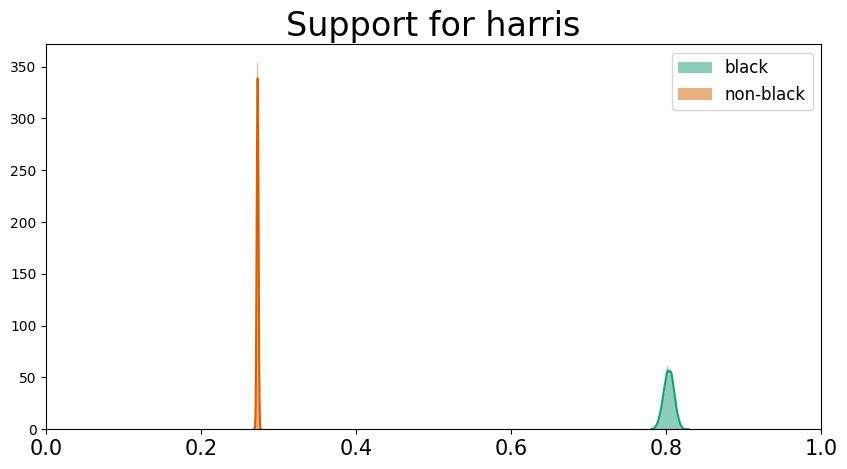

In [15]:
models['harris']['black'].plot_kde()

In [16]:
print(models['harris']['other'].summary())

Model: king99_pareto_modification
        Computed from the raw b_i samples by multiplying by population and then getting
        the proportion of the total pop (total pop=summed across all districts):
        The posterior mean for the district-level voting preference of
        other for harris is
        0.373
        The posterior mean for the district-level voting preference of
        non-other for harris is
        0.332
        95% equal-tailed Bayesian credible interval for district-level voting preference of
        other for harris is
        [0.28782367 0.45841274]
        95% equal-tailed Bayesian credible interval for district-level voting preference of
        non-other for harris is
        [0.32840465 0.3361552 ]
        


### Format Fitted Model Data

In [17]:
posterior_means = models['harris']['white'].posterior_mean_voting_prefs
print("white support for harris", posterior_means[0]) # group
print("non-white support for harris ", posterior_means[1]) # complement

white support for harris 0.22050632928046154
non-white support for harris  0.765555006513946


In [18]:
credible_interval_95 = models['harris']['white'].credible_interval_95_mean_voting_prefs
print("white support for harris", credible_interval_95[0]) # group
print("non-white support for harris ", credible_interval_95[1]) # complement

white support for harris [0.21726838 0.22370506]
non-white support for harris  [0.75417889 0.77727138]


In [19]:
sampled_voting_prefs = models['harris']['white'].sampled_voting_prefs # ei.sampled_voting_prefs is samples of district-level voter preference: list of length 2
#sampled_voting_prefs[0] samples of district-wide support of specified group for specified candidate
#sampled_voting_prefs[1] samples of district-wide support of (complement of specified group) for specified candidate

print("white support for harris", sampled_voting_prefs[0]) # group
print("non-white support for harris ", sampled_voting_prefs[1]) # complement

white support for harris [0.21935178 0.21934243 0.21918049 ... 0.21998498 0.22160449 0.21940292]
non-white support for harris  [0.76440201 0.77645807 0.77575492 ... 0.76527862 0.76385896 0.77027749]


In [20]:

group_samples = sampled_voting_prefs[0]
complement_samples = sampled_voting_prefs[1]

xs = np.linspace(0, 1, 100)
group_density = gaussian_kde(group_samples)(xs)
complement_density = gaussian_kde(complement_samples)(xs)

density_dict = {
    "group": [{"x": float(x), "y": float(y)} for x, y in zip(xs, group_density)],
    "complement": [{"x": float(x), "y": float(y)} for x, y in zip(xs, complement_density)]
}

### Testing Densities

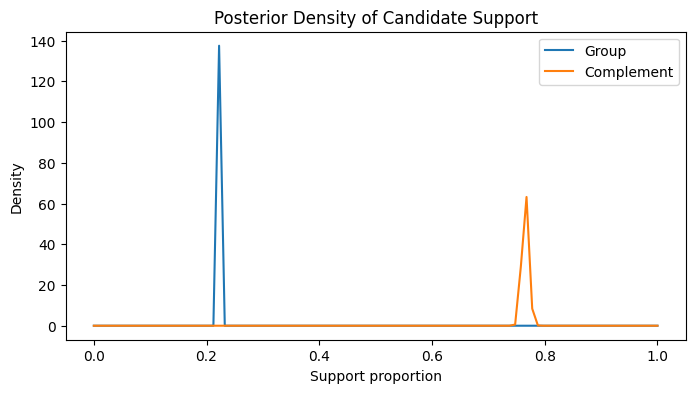

In [21]:
group_xs = [pt['x'] for pt in density_dict['group']]
group_ys = [pt['y'] for pt in density_dict['group']]
comp_xs  = [pt['x'] for pt in density_dict['complement']]
comp_ys  = [pt['y'] for pt in density_dict['complement']]

plt.figure(figsize=(8, 4))
plt.plot(group_xs, group_ys, label="Group")
plt.plot(comp_xs, comp_ys, label="Complement")
plt.xlabel("Support proportion")
plt.ylabel("Density")
plt.title("Posterior Density of Candidate Support")
plt.legend()
plt.show()

### Function to Generate Data

In [22]:
def create_json(models, demographics, candidates):
    ei_json = {"state" : "Arkansas", "candidates": []}

    for candidate in candidates:
        cand_entry = {
            "id": candidate.lower(),
            "groups": {}
        }

        for demographic in demographics:
            model = models[candidate][demographic]

            # posterior means
            group_mean, complement_mean = model.posterior_mean_voting_prefs
            posterior_mean = {
                "group": group_mean,
                "complement": complement_mean
            }

            # credible intervals
            group_ci_95, complement_ci_95 = model.credible_interval_95_mean_voting_prefs
            credible_interval_95 = {
                "group": group_ci_95.tolist(),
                "complement": complement_ci_95.tolist()
            }

            # densities
            sampled_voting_prefs = model.sampled_voting_prefs            
            group_samples = sampled_voting_prefs[0]
            complement_samples = sampled_voting_prefs[1]

            xs = np.linspace(0, 1, 200)
            group_density = gaussian_kde(group_samples)(xs)
            complement_density = gaussian_kde(complement_samples)(xs)

            density = {
                "group": [{"x": float(x), "y": float(y)} for x, y in zip(xs, group_density)],
                "complement": [{"x": float(x), "y": float(y)} for x, y in zip(xs, complement_density)]
            }

            cand_entry["groups"][demographic] = {
                "posterior_mean": posterior_mean,
                "credible_interval_95": credible_interval_95,
                "density": density
            }

        ei_json["candidates"].append(cand_entry)
    
    output_path = "../output/Arkansas/ar_ei_models.json"

    with open(output_path, "w") as f:
        json.dump(ei_json, f, indent=2)            

In [23]:
create_json(models, demographics, candidates)